In [2]:
df = pd.read_csv('qlfs-2022-q2-worker-v1.csv', encoding='latin1', low_memory=False)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (57244, 161)

First 5 rows:


,UQNO,PERSONNO,Q12NIGHTS,Q13GENDER,Q15POPULATION,Q16MARITALSTATUS,Q17EDUCATION,Q18FIELD,Q19ATTE,Q110EDUI,...,sector1,Sector2,Long_term_unempl,Underempl,at_least_1,Infempl,NEET,Geo_type_code,Metro_code,Weight
0,160100720000007101,1,Yes,Male,African/Black,Never married,Grade 4/Standard 2,NaN,No,NaN,...,Agriculture,Formal sector (Including agriculture),NaN,Not underemployed,Not involved in any activity,Formal employment,No,Farms,WC - Non Metro,1007.322238
1,160100720000010801,1,Yes,Male,African/Black,Never married,Grade 11/Standard 9/Form 4,NaN,No,NaN,...,Agriculture,Formal sector (Including agriculture),NaN,Not underemployed,Not involved in any activity,Formal employment,No,Farms,WC - Non Metro,1109.000113
2,160100720000014501,1,Yes,Male,Coloured,Living together like husband and wife,Grade 7/Standard 5/AET 3,NaN,No,NaN,...,Agriculture,Formal sector (Including agriculture),NaN,Not underemployed,Not involved in any activity,Formal employment,No,Farms,WC - Non Metro,1038.794423
3,160100720000014501,2,Yes,Female,Coloured,Married,Grade 9/Standard 7/Form 2/AET 4,NaN,No,NaN,...,NaN,NaN,Long-term unemployment (1 year and longer),NaN,Not involved in any activity,NaN,Yes,Farms,WC - Non Metro,1038.794423
4,160100880000001401,1,Yes,Male,White,Married,Grade 12/Standard 10/Form 5/Matric (No Exemption),NaN,No,NaN,...,Formal sector (non-agricultural),Formal sector (Including agriculture),NaN,Not underemployed,Not involved in any activity,Formal employment,No,Urban,WC - Non Metro,2979.999729


In [3]:
# Focus on youth only (15-24 years)
youth = df[df['age_grp1'].isin(['15-19', '20-24'])]
print("Total youth records:", len(youth))
print("\nNEET breakdown:")
print(youth['NEET'].value_counts())
print("\nNEET percentage:")
print(youth['NEET'].value_counts(normalize=True) * 100)

Total youth records: 9546

NEET breakdown:
NEET
No     6192
Yes    3354
Name: count, dtype: int64

NEET percentage:
NEET
No     64.864865
Yes    35.135135
Name: proportion, dtype: float64


In [4]:
# NEET breakdown by province
print("NEET by Province:")
neet_province = youth.groupby('Province')['NEET'].value_counts(normalize=True).unstack() * 100
print(neet_province.round(1))

print("\nNEET by Population Group:")
neet_pop = youth.groupby('Q15POPULATION')['NEET'].value_counts(normalize=True).unstack() * 100
print(neet_pop.round(1))

print("\nNEET by Education Status:")
neet_edu = youth.groupby('Education_Status')['NEET'].value_counts(normalize=True).unstack() * 100
print(neet_edu.round(1))

NEET by Province:
NEET             No   Yes
Province                 
Eastern Cape   65.3  34.7
Free State     64.9  35.1
Gauteng        63.6  36.4
KwaZulu-Natal  63.9  36.1
Limpopo        71.5  28.5
Mpumalanga     65.2  34.8
North West     58.4  41.6
Northern Cape  54.8  45.2
Western Cape   69.5  30.5

NEET by Population Group:
NEET             No   Yes
Q15POPULATION            
African/Black  64.3  35.7
Coloured       63.0  37.0
Indian/Asian   78.5  21.5
White          85.8  14.2

NEET by Education Status:
NEET                           No   Yes
Education_Status                       
Less than primary completed  50.5  49.5
No schooling                 15.6  84.4
Other                        57.6  42.4
Primary completed            73.9  26.1
Secondary completed          44.9  55.1
Secondary not completed      76.1  23.9
Tertiary                     53.6  46.4


In [6]:
# NEET by gender
print("NEET by Gender:")
neet_gender = youth.groupby('Q13GENDER')['NEET'].value_counts(normalize=True).unstack() * 100
print(neet_gender.round(1))

NEET by Gender:
NEET         No   Yes
Q13GENDER            
Female     62.8  37.2
Male       66.9  33.1


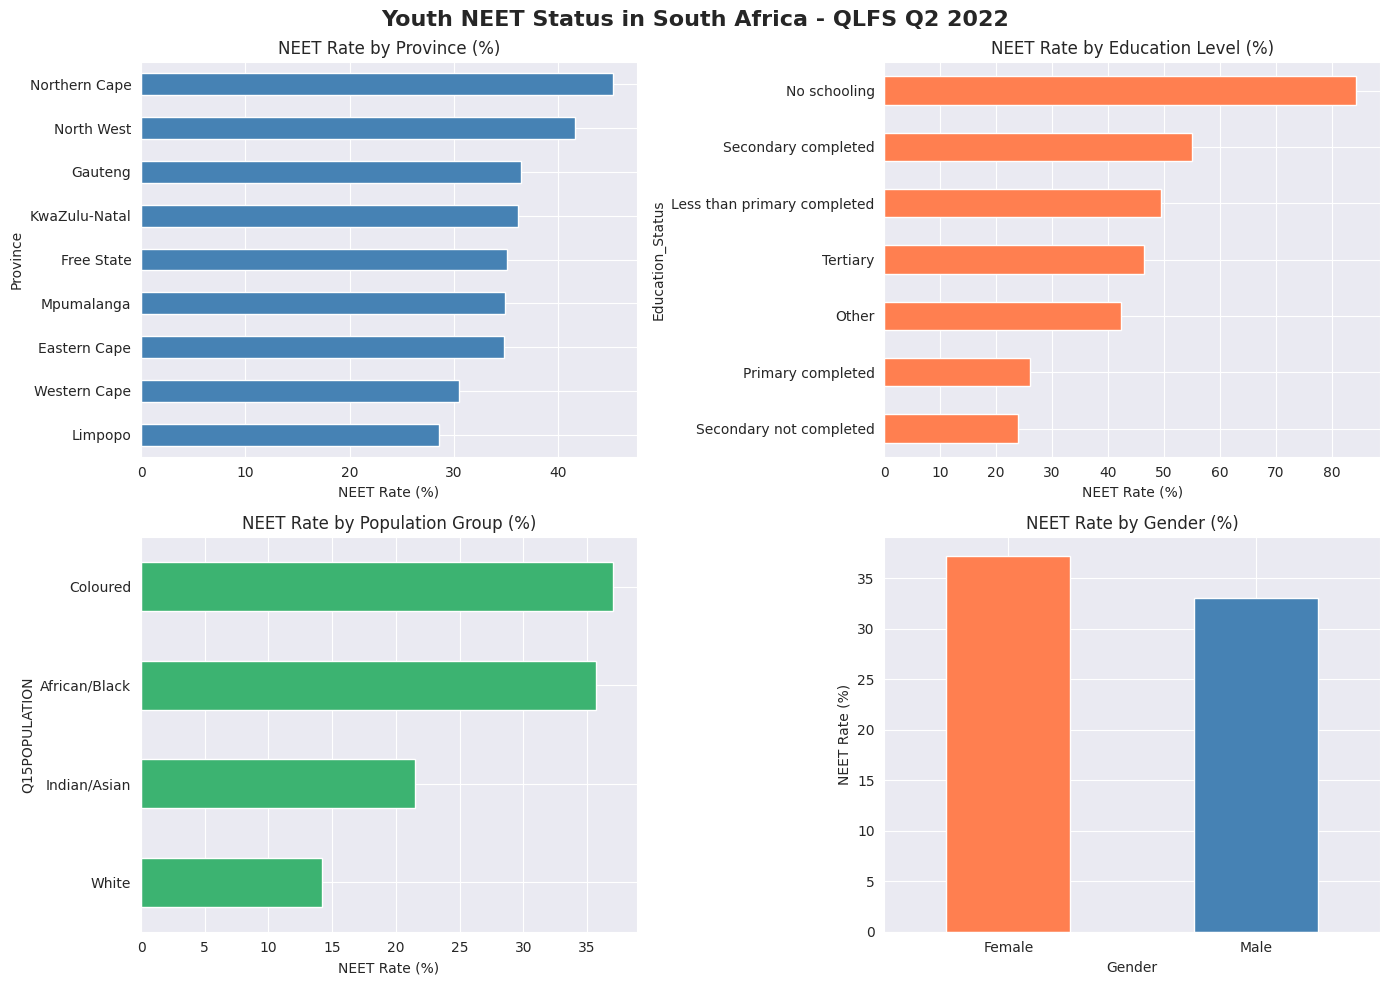

Chart saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Youth NEET Status in South Africa - QLFS Q2 2022', fontsize=16, fontweight='bold')

# 1. NEET by Province
neet_province['Yes'].sort_values().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('NEET Rate by Province (%)')
axes[0,0].set_xlabel('NEET Rate (%)')

# 2. NEET by Education
neet_edu['Yes'].sort_values().plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('NEET Rate by Education Level (%)')
axes[0,1].set_xlabel('NEET Rate (%)')

# 3. NEET by Population Group
neet_pop['Yes'].sort_values().plot(kind='barh', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('NEET Rate by Population Group (%)')
axes[1,0].set_xlabel('NEET Rate (%)')

# 4. NEET by Gender
neet_gender['Yes'].plot(kind='bar', ax=axes[1,1], color=['coral', 'steelblue'])
axes[1,1].set_title('NEET Rate by Gender (%)')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('NEET Rate (%)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('neet_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

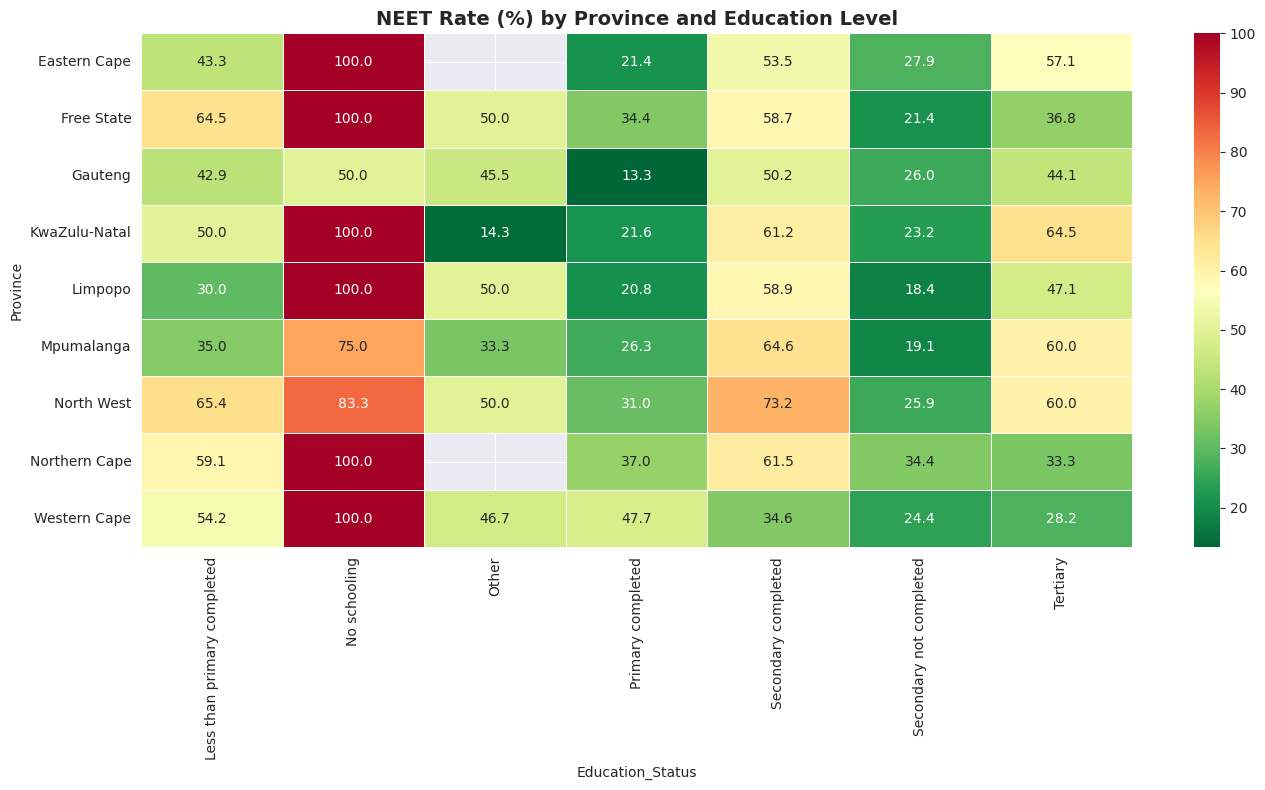

In [8]:
# How does education interact with province?
pivot = youth.groupby(['Province', 'Education_Status'])['NEET'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('NEET Rate (%) by Province and Education Level',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('neet_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Create our modelling dataset
# Filter to youth only and drop rows where NEET is null
model_df = youth[youth['NEET'].notna()].copy()

print("Records for modelling:", len(model_df))
print("\nTarget variable distribution:")
print(model_df['NEET'].value_counts())

# Select our features
features = ['Q13GENDER', 'Q15POPULATION', 'Province',
            'Education_Status', 'Q19ATTE', 'age_grp1']

print("\nMissing values in selected features:")
print(model_df[features].isnull().sum())

Records for modelling: 9546

Target variable distribution:
NEET
No     6192
Yes    3354
Name: count, dtype: int64

Missing values in selected features:
Q13GENDER           0
Q15POPULATION       0
Province            0
Education_Status    0
Q19ATTE             0
age_grp1            0
dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
model_encoded = model_df[features + ['NEET']].copy()

# Encode target variable
model_encoded['NEET'] = (model_encoded['NEET'] == 'Yes').astype(int)

# Encode features
le = LabelEncoder()
for col in features:
    model_encoded[col] = le.fit_transform(model_encoded[col].astype(str))

print("Encoded dataset shape:", model_encoded.shape)
print("\nFirst 5 rows:")
print(model_encoded.head())
print("\nTarget distribution:")
print(model_encoded['NEET'].value_counts())

Encoded dataset shape: (9546, 7)

First 5 rows:
    Q13GENDER  Q15POPULATION  Province  Education_Status  Q19ATTE  age_grp1  \
6           0              3         8                 4        0         1   
7           1              3         8                 4        1         0   
8           1              3         8                 5        1         0   
9           1              3         8                 6        0         1   
18          0              1         8                 5        1         0   

    NEET  
6      0  
7      0  
8      0  
9      0  
18     0  

Target distribution:
NEET
0    6192
1    3354
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Separate features and target
X = model_df[features].copy()
y = (model_df['NEET'] == 'Yes').astype(int)

# One hot encode
ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), features)
    ]
)

X_encoded = ct.fit_transform(X)

print("Original feature count:", len(features))
print("Encoded feature count:", X_encoded.shape[1])
print("Total records:", X_encoded.shape[0])

Original feature count: 6
Encoded feature count: 20
Total records: 9546


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# Train logistic regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate
y_pred = lr_model.predict(X_test)
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not NEET', 'NEET']))

Training set size: 7636
Testing set size: 1910

Accuracy: 91.41 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.98      0.88      0.93      1239
        NEET       0.82      0.97      0.89       671

    accuracy                           0.91      1910
   macro avg       0.90      0.93      0.91      1910
weighted avg       0.93      0.91      0.92      1910



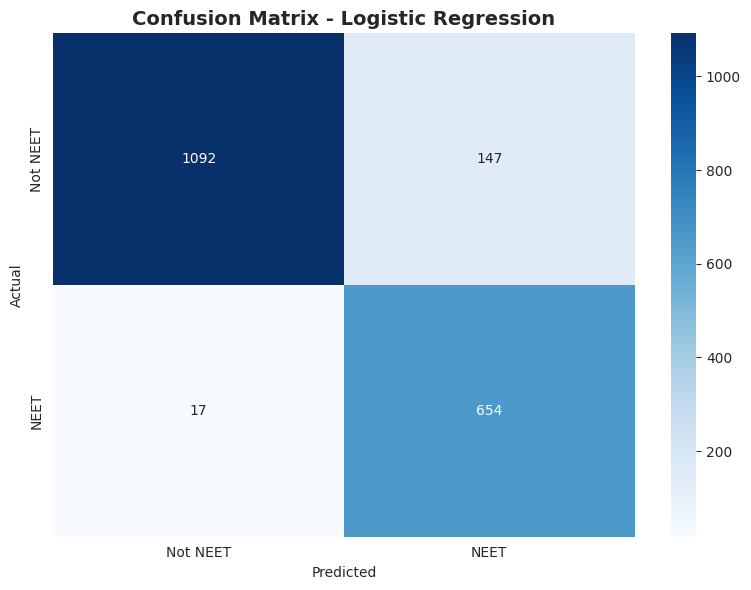

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not NEET', 'NEET'],
            yticklabels=['Not NEET', 'NEET'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not NEET', 'NEET']))

Accuracy: 90.94 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.97      0.89      0.93      1239
        NEET       0.82      0.95      0.88       671

    accuracy                           0.91      1910
   macro avg       0.90      0.92      0.90      1910
weighted avg       0.92      0.91      0.91      1910



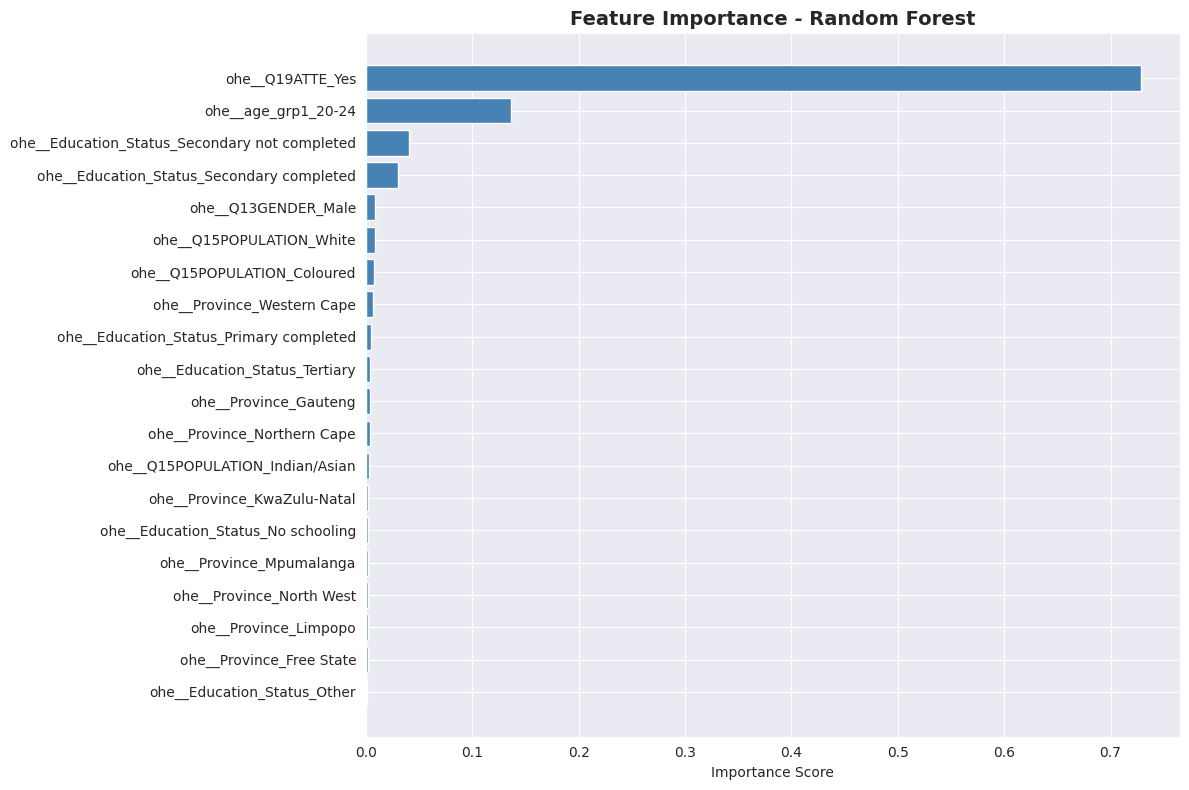

In [15]:
# Get feature names after one hot encoding
feature_names = ct.get_feature_names_out()

# Feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.barh(range(len(importances)),
         importances[indices][::-1],
         color='steelblue')
plt.yticks(range(len(importances)),
           [feature_names[i] for i in indices][::-1])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Remove Q19ATTE - data leakage
features_clean = ['Q13GENDER', 'Q15POPULATION', 'Province',
                  'Education_Status', 'age_grp1']

X_clean = model_df[features_clean].copy()
y = (model_df['NEET'] == 'Yes').astype(int)

ct_clean = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), features_clean)
    ]
)

X_clean_encoded = ct_clean.fit_transform(X_clean)

X_train, X_test, y_train, y_test = train_test_split(
    X_clean_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain logistic regression
lr_model2 = LogisticRegression(max_iter=1000, random_state=42)
lr_model2.fit(X_train, y_train)
y_pred2 = lr_model2.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred2) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=['Not NEET', 'NEET']))

Accuracy: 72.3 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.78      0.80      0.79      1239
        NEET       0.61      0.58      0.59       671

    accuracy                           0.72      1910
   macro avg       0.70      0.69      0.69      1910
weighted avg       0.72      0.72      0.72      1910



In [17]:
# Random Forest with clean features
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model2.fit(X_train, y_train)
y_pred_rf2 = rf_model2.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_rf2) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf2, target_names=['Not NEET', 'NEET']))

Accuracy: 72.72 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.87      0.68      0.76      1239
        NEET       0.58      0.82      0.68       671

    accuracy                           0.73      1910
   macro avg       0.73      0.75      0.72      1910
weighted avg       0.77      0.73      0.73      1910



In [18]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not NEET', 'NEET']))

Accuracy: 73.25 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.88      0.68      0.77      1239
        NEET       0.58      0.83      0.69       671

    accuracy                           0.73      1910
   macro avg       0.73      0.75      0.73      1910
weighted avg       0.78      0.73      0.74      1910



In [19]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': lr_model2,
    'Random Forest': rf_model2,
    'XGBoost': xgb_model
}

print("10-Fold Cross Validation Results:")
print("-" * 45)

for name, model in models.items():
    scores = cross_val_score(
        model, X_clean_encoded, y,
        cv=10, scoring='recall'
    )
    print(f"{name}:")
    print(f"  Mean Recall: {scores.mean():.3f}")
    print(f"  Std Dev: {scores.std():.3f}")
    print()

10-Fold Cross Validation Results:
---------------------------------------------
Logistic Regression:
  Mean Recall: 0.406
  Std Dev: 0.251

Random Forest:
  Mean Recall: 0.639
  Std Dev: 0.309

XGBoost:
  Mean Recall: 0.683
  Std Dev: 0.301



In [20]:
import pandas as pd

files = {
    '2019 Q2': 'qlfs-2019-q2-worker-v1.0.csv',
    '2020 Q2': 'qlfs-2020-q2-worker-v2.1.csv',
    '2021 Q2': 'qlfs-2021-q2-worker-v1.csv',
    '2022 Q2': 'qlfs-2022-q2-worker-v1.csv',
    '2023 Q2': 'qlfs-2023-q2-worker-v1.csv'
}

for year, file in files.items():
    try:
        df_temp = pd.read_csv(file, encoding='latin1', low_memory=False)
        neet_col = 'NEET' in df_temp.columns
        print(f"{year}: {df_temp.shape[0]} rows, {df_temp.shape[1]} cols, NEET column: {neet_col}")
    except Exception as e:
        print(f"{year}: ERROR - {e}")

2019 Q2: 67626 rows, 161 cols, NEET column: True
2020 Q2: 47103 rows, 171 cols, NEET column: True
2021 Q2: 53940 rows, 161 cols, NEET column: True
2022 Q2: 57244 rows, 161 cols, NEET column: True
2023 Q2: 66628 rows, 161 cols, NEET column: True


In [21]:
dfs = {}
for year, file in files.items():
    dfs[year] = pd.read_csv(file, encoding='latin1', low_memory=False)

# Find common columns across all years
common_cols = set(dfs['2019 Q2'].columns)
for year, df in dfs.items():
    common_cols = common_cols.intersection(set(df.columns))

print("Common columns across all years:", len(common_cols))

# Find what 2020 has extra
extra_2020 = set(dfs['2020 Q2'].columns) - common_cols
print("\nExtra columns in 2020 Q2:", extra_2020)

Common columns across all years: 158

Extra columns in 2020 Q2: {'Q515FULLSALARY', 'Q517LOSEJOB', 'Q510COMPANY', 'Q47AcLEAVE', 'Q516SAMEJOB', 'Q511WORK', 'Q513PREVENT', 'Q514RECEIVEPAY', 'Q512PLACE', 'Q513BOTHER', 'geo_type_qlfs', 'Sector1', 'Q47BcSICK'}


In [22]:
# Stack all years using common columns only
combined = []

for year, df in dfs.items():
    df_subset = df[list(common_cols)].copy()
    df_subset['survey_year'] = year
    combined.append(df_subset)

df_all = pd.concat(combined, ignore_index=True)

print("Combined dataset shape:", df_all.shape)
print("\nRecords per year:")
print(df_all['survey_year'].value_counts().sort_index())

# Filter to youth
youth_all = df_all[df_all['age_grp1'].isin(['15-19', '20-24'])]
print("\nTotal youth records:", len(youth_all))
print("\nNEET distribution:")
print(youth_all['NEET'].value_counts())

Combined dataset shape: (292541, 159)

Records per year:
survey_year
2019 Q2    67626
2020 Q2    47103
2021 Q2    53940
2022 Q2    57244
2023 Q2    66628
Name: count, dtype: int64

Total youth records: 48948

NEET distribution:
NEET
No     32936
Yes    16012
Name: count, dtype: int64


In [23]:
# Prepare combined dataset for modelling
features_clean = ['Q13GENDER', 'Q15POPULATION', 'Province',
                  'Education_Status', 'age_grp1']

youth_model = youth_all[youth_all['NEET'].notna()].copy()

X_full = youth_model[features_clean].copy()
y_full = (youth_model['NEET'] == 'Yes').astype(int)

ct_full = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), features_clean)
    ]
)

X_full_encoded = ct_full.fit_transform(X_full)

X_train, X_test, y_train, y_test = train_test_split(
    X_full_encoded, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("Training set:", X_train.shape[0], "records")
print("Testing set:", X_test.shape[0], "records")

xgb_full = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

xgb_full.fit(X_train, y_train)
y_pred_full = xgb_full.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred_full) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_full, target_names=['Not NEET', 'NEET']))

Training set: 39158 records
Testing set: 9790 records

Accuracy: 72.66 %

Classification Report:
              precision    recall  f1-score   support

    Not NEET       0.90      0.66      0.77      6587
        NEET       0.55      0.85      0.67      3203

    accuracy                           0.73      9790
   macro avg       0.73      0.76      0.72      9790
weighted avg       0.79      0.73      0.73      9790



In [24]:
scores_full = cross_val_score(
    xgb_full, X_full_encoded, y_full,
    cv=10, scoring='recall'
)

print("10-Fold Cross Validation - XGBoost Full Dataset:")
print(f"Mean Recall: {scores_full.mean():.3f}")
print(f"Std Dev: {scores_full.std():.3f}")
print(f"Min: {scores_full.min():.3f}")
print(f"Max: {scores_full.max():.3f}")

10-Fold Cross Validation - XGBoost Full Dataset:
Mean Recall: 0.857
Std Dev: 0.021
Min: 0.818
Max: 0.892


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully
